# Notebook 2 — Why 36-bit RNS modular multiplication is awkward

This notebook explains the arithmetic problem behind 36-bit RNS limbs in fully-homomorphic encryption (FHE)-style schemes. **RNS** (residue number system): a large integer is stored as residues modulo several smaller primes, so each big-integer operation decomposes into independent per-limb operations.

**Prerequisites:** Notebook 1 (binary multiplication and Booth recoding).  
**Reading time:** about 20 minutes.

The thesis: a single RNS limb modulus near $q \approx 2^{36}$ produces raw products near $q^2 \approx 2^{72}$, which **does not fit in a 64-bit machine word**. That single fact drives the rest of the series.

In [1]:
import numpy as np
import pandas as pd
from ipywidgets import IntSlider, interact

from rns_arithmetic import booth, limb_decompose, visualization

visualization.apply_style()
rng = np.random.default_rng(seed=20260426)

## 2.1 What is an RNS limb?

**Takeaway:** RNS represents one large integer as several small-integer residues. Each residue is independent, so per-limb operations can be parallelized.

Given pairwise-coprime moduli $q_0, q_1, \ldots, q_{L-1}$, an integer $X$ in the range $[0, \prod_i q_i)$ is represented by its residue tuple

$$
X \;\longleftrightarrow\; (X \bmod q_0,\; X \bmod q_1,\; \ldots,\; X \bmod q_{L-1}).
$$

Each $q_i$ is called an **RNS prime** or **RNS limb**. Multiplication is component-wise:

$$
c_i \;=\; (a_i \cdot b_i) \bmod q_i.
$$

Cryptosystems like CKKS (a common FHE scheme) use *many* such modular multiplications inside the number-theoretic transform (NTT), key switching, rescaling, and bootstrapping. The per-limb cost dominates total runtime, so it is the right unit to optimize.

## 2.2 Product width vs. prime size

**Takeaway:** if the prime is $w$ bits, the raw product is $2w$ bits. The 64-bit boundary is the relevant cliff for commodity scalar arithmetic.

The table below tabulates this, and the widget below it lets you sweep `prime_bits` interactively.

In [2]:
rows = []
for w in [20, 30, 31, 32, 36, 50, 60]:
    rows.append(
        {
            "prime_bits": w,
            "product_bits": 2 * w,
            "fits_uint64": 2 * w <= 64,
            "fits_signed_int64": 2 * w <= 63,
        }
    )
pd.DataFrame(rows)

,prime_bits,product_bits,fits_uint64,fits_signed_int64
0,20,40,True,True
1,30,60,True,True
2,31,62,True,True
3,32,64,True,False
4,36,72,False,False
5,50,100,False,False
6,60,120,False,False


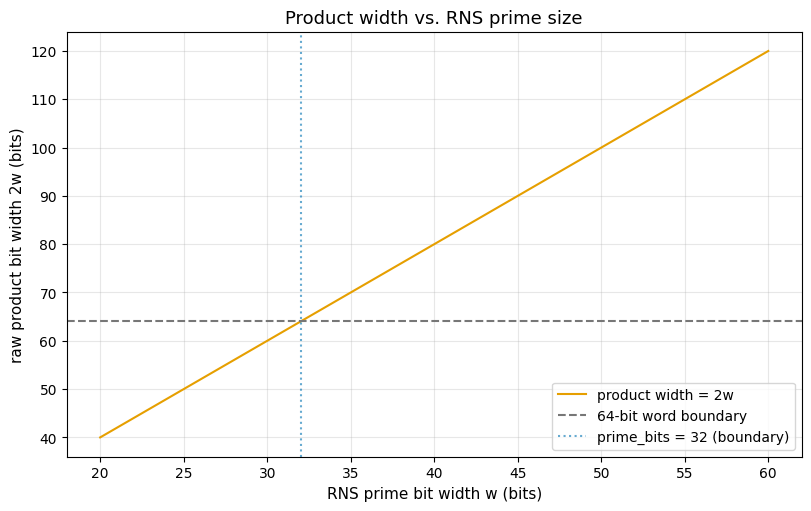

In [3]:
import matplotlib.pyplot as plt

fig = visualization.plot_product_width_vs_prime_bits(range(20, 61))
plt.show()

### Interactive: sweep prime size

Drag the slider to see whether a single raw product fits in common machine widths. The static cell below shows the default of 36 bits (the awkward case).

In [4]:
def show_widths(prime_bits: int) -> None:
    product_bits = 2 * prime_bits
    print(f"prime_bits          = {prime_bits}")
    print(f"raw product bits    = {product_bits}")
    print(f"fits in uint32?     = {product_bits <= 32}")
    print(f"fits in uint64?     = {product_bits <= 64}")
    print(f"fits in int64?      = {product_bits <= 63}  (signed: one bit reserved)")
    print(f"fits in __uint128_t = {product_bits <= 128}")


show_widths(36)

prime_bits          = 36
raw product bits    = 72
fits in uint32?     = False
fits in uint64?     = False
fits in int64?      = False  (signed: one bit reserved)
fits in __uint128_t = True


In [5]:
interact(show_widths, prime_bits=IntSlider(value=36, min=20, max=60, description="prime_bits"));

interactive(children=(IntSlider(value=36, description='prime_bits', max=60, min=20), Output()), _dom_classes=(…

## 2.3 Reference implementation in Python big integers

**Takeaway:** Python integers are arbitrary precision, so the reference is correct *but is not representative of commodity machine-word cost*. Use it only as a correctness oracle, not as a performance baseline.

In [6]:
def mul_mod_reference(a: int, b: int, q: int) -> int:
    return (a * b) % q


q = (1 << 36) - 5  # nearby 36-bit modulus (not necessarily prime, illustrative only)
a = int(rng.integers(0, q, dtype=np.uint64))
b = int(rng.integers(0, q, dtype=np.uint64))
print(f"q = 2^36 - 5  ({q.bit_length()} bits)")
print(f"a = {a}  ({a.bit_length()} bits)")
print(f"b = {b}  ({b.bit_length()} bits)")
print(f"raw a * b   has {(a * b).bit_length()} bits")
print(f"(a * b) % q = {mul_mod_reference(a, b, q)}")

q = 2^36 - 5  (36 bits)
a = 40622410579  (36 bits)
b = 23115661149  (35 bits)
raw a * b   has 70 bits
(a * b) % q = 62267612690


## 2.4 NumPy `uint64` silently truncates a 72-bit product

**Takeaway:** NumPy `uint64` arithmetic wraps modulo $2^{64}$ — the high 8 bits of a 72-bit product are *silently discarded*. This is the most important demonstration in this notebook.

If you tried to compute 36-bit modular multiplication using `(a * b) % q` on `np.uint64` arrays — the natural NumPy idiom — the result is *wrong*, and there is no warning.

In [7]:
a_u64 = np.uint64((1 << 36) - 1)
b_u64 = np.uint64((1 << 36) - 1)

with np.errstate(over="ignore"):
    p_u64 = a_u64 * b_u64

p_python = int(a_u64) * int(b_u64)
lost_high_bits = p_python >> 64  # the silently-discarded high bits

print(f"a_u64 = {int(a_u64)}  ({int(a_u64).bit_length()} bits)")
print(f"b_u64 = {int(b_u64)}  ({int(b_u64).bit_length()} bits)")
print(f"a*b in Python int   = {p_python}  ({p_python.bit_length()} bits)")
print(f"a*b in uint64        = {int(p_u64)}  (low 64 bits only)")
print(f"high bits discarded = {lost_high_bits}  (= the lost top {p_python.bit_length() - 64} bits)")
print(f"silent truncation?  = {int(p_u64) != p_python}")

a_u64 = 68719476735  (36 bits)
b_u64 = 68719476735  (36 bits)
a*b in Python int   = 4722366482732206260225  (72 bits)
a*b in uint64        = 18446743936270598145  (low 64 bits only)
high bits discarded = 255  (= the lost top 8 bits)
silent truncation?  = True


## 2.5 36-bit multiplication via 32-bit chunks

**Takeaway:** the practical commodity-software view of a $36 \times 36 \to 72$ product is **four chunk products** at the 32-bit boundary, recomposed with shifts.

Split each operand at the 32-bit boundary,

$$
a \;=\; a_0 + 2^{32} a_1, \qquad b \;=\; b_0 + 2^{32} b_1,
$$

where $a_0, b_0$ are 32-bit and $a_1, b_1$ are 4-bit (since the operands are 36-bit). Then

$$
ab \;=\; a_0 b_0 \;+\; 2^{32}(a_0 b_1 + a_1 b_0) \;+\; 2^{64} a_1 b_1.
$$

Four conceptual products: one 32×32 → up to 64 bits, two 32×4 → up to 36 bits, one 4×4 → up to 8 bits. The result occupies three 32-bit words.

`limb_decompose.product_36_as_32_words(a, b)` implements this directly.

In [8]:
samples = rng.integers(0, 1 << 36, size=(5, 2), dtype=np.uint64)
rows = []
for a, b in samples.tolist():
    chunked = limb_decompose.product_36_as_32_words(int(a), int(b))
    reference = int(a) * int(b)
    rows.append(
        {
            "a": int(a),
            "b": int(b),
            "chunked": chunked,
            "reference": reference,
            "match": chunked == reference,
        }
    )
pd.DataFrame(rows)

,a,b,chunked,reference,match
0,18292627327,66632533281,1218884099163257569887,1218884099163257569887,True
1,55147582921,11398063506,628575652335958981026,628575652335958981026,True
2,19756759817,29317475448,579218320866930473016,579218320866930473016,True
3,50532350883,4130746731,208736343219697213473,208736343219697213473,True
4,13949830527,177955721,2482452149260094967,2482452149260094967,True


## 2.6 Compare against Booth

**Takeaway:** for software on commodity word-arithmetic CPUs, **a few native word multiplications are usually better than many shifted multiword add/sub operations**. Booth's row reduction is real but does not help past the multiword recomposition cost.

For 36-bit operands:

- Radix-4 Booth: ~13.5 expected non-zero signed partial-product rows on top of multiword-add machinery.
- 32-bit chunk decomposition: 4 conceptual products plus carry/recomposition.

On commodity x86-64 / AArch64 CPUs, four `mul`/`umulh` instructions plus a couple of shifts and adds is straightforward; emulating Booth's signed-partial-product loop in software is not.

In [9]:
row_booth = booth.booth_radix4_cost(36)
row_naive = booth.naive_shift_add_cost(36)
row_chunk = {"groups": 4, "expected_nonzero_partial_rows": 4.0}  # all four chunk products are dense
df = pd.DataFrame(
    [
        {"method": "naive shift-add (36 bits)", **row_naive},
        {"method": "radix-4 Booth (36 bits)", **row_booth},
        {"method": "32-bit chunk decomposition (36 bits)", **row_chunk},
    ]
)
df.rename(
    columns={
        "groups": "structural rows / products",
        "expected_nonzero_partial_rows": "expected non-zero rows / products",
    }
)

,method,structural rows / products,expected non-zero rows / products
0,naive shift-add (36 bits),36,18.0
1,radix-4 Booth (36 bits),18,13.5
2,32-bit chunk decomposition (36 bits),4,4.0


## Takeaway

- 36-bit modular multiplication is awkward because the **raw product is 72 bits**, larger than a single 64-bit machine word.
- Naively using NumPy `uint64` for $a \cdot b$ silently truncates the high 8 bits — the result is wrong without warning.
- The honest commodity-software model is **chunked multiplication**: four 32-bit-chunk cross-products, recomposed with shifts. Three words of accumulator, then a modular reduction.
- Booth-style shift-add reduces the number of partial-product rows but still needs a multiword accumulator — on commodity word arithmetic, native multiplications win.
- Notebook 3 takes the natural next step: instead of fighting 36-bit primes, **choose RNS prime sizes whose products fit native word widths**.